Preprocessing + DataLoaders

In [40]:
!pip install imbalanced-learn
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Layers equivalents in PyTorch
# (We'll define LSTM, GRU, Dense layers inside a custom nn.Module later)
from torch.nn import LSTM, GRU, Linear, Dropout, BatchNorm1d

# Sklearn preprocessing & metrics
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, roc_auc_score, accuracy_score, f1_score
# Data balancing & missing value handling
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [41]:
import torch
print(torch.__version__)
print(torch.version.cuda)


2.7.1+cu118
11.8


In [42]:
# Load the dataset
df = pd.read_csv('/home/usman/Desktop/TextDL/Datasets/dhi.csv')

# Display the first few rows of the dataset
df

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


In [43]:
import pandas as pd

# Load CSV
df = pd.read_csv('/home/usman/Desktop/TextDL/Datasets/dhi.csv')

# Drop duplicates
df.drop_duplicates(inplace=True)

# Show info
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 229474 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       229474 non-null  float64
 1   HighBP                229474 non-null  float64
 2   HighChol              229474 non-null  float64
 3   CholCheck             229474 non-null  float64
 4   BMI                   229474 non-null  float64
 5   Smoker                229474 non-null  float64
 6   Stroke                229474 non-null  float64
 7   HeartDiseaseorAttack  229474 non-null  float64
 8   PhysActivity          229474 non-null  float64
 9   Fruits                229474 non-null  float64
 10  Veggies               229474 non-null  float64
 11  HvyAlcoholConsump     229474 non-null  float64
 12  AnyHealthcare         229474 non-null  float64
 13  NoDocbcCost           229474 non-null  float64
 14  GenHlth               229474 non-null  float64
 15  MentH

In [44]:
import torch
from sklearn.preprocessing import MinMaxScaler

# Separate features and target variable
X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']

# Normalize numerical features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Convert to PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y.values, dtype=torch.float32)  # float32 if BCE loss, long if CrossEntropy


In [45]:
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import torch

# Impute missing values
imputer = SimpleImputer(strategy='mean')  # Could be 'median', 'most_frequent', etc.
X_imputed = imputer.fit_transform(X)

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=32)
X_smote, y_smote = smote.fit_resample(X_imputed, y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=32
)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)  # or long if CE loss
y_test = torch.tensor(y_test, dtype=torch.float32)


In [46]:
# Reshape for LSTM: (batch_size, seq_length, features)
X_train_lstm = X_train.view(X_train.shape[0], X_train.shape[1], 1)
X_test_lstm = X_test.view(X_test.shape[0], X_test.shape[1], 1)

Model Defination

In [47]:
"""import torch
import torch.nn as nn
import torch.nn.functional as F
        self.drop1 = nn.Dropout(0.4)    # ↑ dropout a bit
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)          # (batch, seq_len, 256)
        x = torch.mean(lstm_out, dim=1)     # mean pooling


class BiLSTM_Model(nn.Module):
    def __init__(self, input_size):
        super(BiLSTM_Model, self).__init__()

        # BiLSTM
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=64,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        # Dense layers
        self.fc1 = nn.Linear(128, 64)   # 64*2 because bidirectional
        self.drop1 = nn.Dropout(0.4)    # ↑ dropout a bit
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)          # (batch, seq_len, 256)
        x = torch.mean(lstm_out, dim=1)     # mean pooling

        self.drop1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, 1)     # Binary classification

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        lstm_out, _ = self.lstm(x)          # (batch, seq_len, 128)
        x = torch.mean(lstm_out, dim=1)     # Global average pooling (batch, 128)

        x = F.relu(self.fc1(x))
        x = self.drop1(x)

        return self.fc2(x)  # logits (use BCEWithLogitsLoss)"""

import torch
import torch.nn as nn
import torch.nn.functional as F

class BiLSTM_Model(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        # BiLSTM with 2 layers, bidirectional
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.2
        )
        # Dense layers
        self.fc1 = nn.Linear(128*2, 128)  # bidirectional → 256
        self.bn1 = nn.BatchNorm1d(128)
        self.drop1 = nn.Dropout(0.4)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)       # (batch, seq_len, 256)
        x = torch.mean(lstm_out, dim=1)  # mean pooling over seq_len
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop1(x)
        return self.fc2(x)  # logits

In [48]:
input_size = X_train_lstm.shape[2]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BiLSTM_Model(input_size=input_size).to(DEVICE)

Traiming Loop

In [49]:
'''import torch
import torch.optim as optim
from torch.utipip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118ls.data import TensorDataset, DataLoader
import numpy as np
import torch.nn as nn
# Create Dataset & DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

val_split = 0.2
val_size = int(len(train_dataset) * val_split)
train_size = len(train_dataset) - val_size
train_subset, val_subset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)

# Initialize model
input_size = X_train_lstm.shape[2]   # feature size per timestep
model = BiLSTM_Model(input_size=input_size)
from sklearn.metrics import f1_score

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train_lstm, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_lstm, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Create Dataset & DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

val_split = 0.2
val_size = int(len(train_dataset) * val_split)
train_size = len(train_dataset) - val_size
train_subset, val_subset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)

# Initialize model
input_size = X_train_lstm.shape[2]   # feature size per timestep
model = BiLSTM_Model(input_size=input_size)

# Loss & optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

# Early stopping
patience = 30
best_val_loss = float('inf')
epochs_no_improve = 0

# Storage for metrics
train_accs, val_accs = [], []
train_losses, val_losses = [], []
train_f1s, val_f1s = [], []

# Training loop
num_epochs = 350
for epoch in range(num_epochs):
    model.train()
    train_loss, correct, total = 0, 0, 0
    y_true_train, y_pred_train = [], []

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct += preds.eq(y_batch).sum().item()
        total += y_batch.size(0)

        y_true_train.extend(y_batch.cpu().numpy())
        y_pred_train.extend(preds.cpu().numpy())

    train_loss /= len(train_loader)
    train_accuracy = correct / total
    train_f1 = f1_score(y_true_train, y_pred_train, average="binary")

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    y_true_val, y_pred_val = [], []

    with torch.no_grad():
        for X_val, y_val in val_loader:
            outputs = model(X_val)
            loss = criterion(outputs, y_val)
            val_loss += loss.item()

            preds = (torch.sigmoid(outputs) >= 0.5).float()
            val_correct += preds.eq(y_val).sum().item()
            val_total += y_val.size(0)

            y_true_val.extend(y_val.cpu().numpy())
            y_pred_val.extend(preds.cpu().numpy())

    val_loss /= len(val_loader)

    val_accuracy = val_correct / val_total
    val_f1 = f1_score(y_true_val, y_pred_val, average="binary")

    # Save metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_accuracy)
    val_accs.append(val_accuracy)
    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, Train F1: {train_f1:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}, Val F1: {val_f1:.4f}")

    scheduler.step(val_loss)

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pth")

    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(torch.load("best_model.pth"))

# Test evaluation
model.eval()
with torch.no_grad():
    y_pred_logits = model(X_test_tensor)
    test_loss = criterion(y_pred_logits, y_test_tensor).item()
    y_pred_class = (torch.sigmoid(y_pred_logits) >= 0.5).floapip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118t()
    test_accuracy = (y_pred_class.eq(y_test_tensor).sum() / len(y_test_tensor)).item()

    # Compute test F1
    test_f1 = f1_score(y_test_tensor.cpu().numpy(), y_pred_class.cpu().numpy(), average="binary")

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test F1: {test_f1:.4f}")'''

'''import torch
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import torch.nn as nn
from sklearn.metrics import f1_score, accuracy_score

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train_lstm, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_lstm, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Create Dataset & DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

val_split = 0.2
val_size = int(len(train_dataset) * val_split)
train_size = len(train_dataset) - val_size
train_subset, val_subset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)

# Initialize model
input_size = X_train_lstm.shape[2]   # feature size per timestep
model = BiLSTM_Model(input_size=input_size)

# Loss & optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

# Early stopping
patience = 30
best_val_loss = float('inf')
epochs_no_improve = 0

# Storage for metrics
train_accs, val_accs = [], []
train_losses, val_losses = [], []
train_f1s, val_f1s = [], []

# Training loop
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    train_loss, correct, total = 0, 0, 0
    y_true_train, y_pred_train = [], []

    for X_batch, y_batch in train_loader:
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct += preds.eq(y_batch).sum().item()
        total += y_batch.size(0)

        y_true_train.extend(y_batch.cpu().numpy())
        y_pred_train.extend(preds.cpu().numpy())

    train_loss /= len(train_loader)
    train_accuracy = correct / total
    train_f1 = f1_score(y_true_train, y_pred_train, average="binary")

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    y_true_val, y_pred_val = [], []

    with torch.no_grad():
        for X_val, y_val in val_loader:
            outputs = model(X_val)
            loss = criterion(outputs, y_val)
            val_loss += loss.item()

            preds = (torch.sigmoid(outputs) >= 0.5).float()
            val_correct += preds.eq(y_val).sum().item()
            val_total += y_val.size(0)

            y_true_val.extend(y_val.cpu().numpy())
            y_pred_val.extend(preds.cpu().numpy())

    val_loss /= len(val_loader)
    val_accuracy = val_correct / val_total
    val_f1 = f1_score(y_true_val, y_pred_val, average="binary")

    # Save metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_accuracy)
    val_accs.append(val_accuracy)
    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, Train F1: {train_f1:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}, Val F1: {val_f1:.4f}")

    scheduler.step(val_loss)

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(torch.load("best_model.pth"))

# ================================
# 🔹 Threshold tuning on validation
# ================================
model.eval()
val_probs, val_true = [], []
with torch.no_grad():
    for X_val, y_val in val_loader:
        outputs = model(X_val)
        probs = torch.sigmoid(outputs).cpu().numpy().ravel()
        val_probs.extend(probs)
        val_true.extend(y_val.cpu().numpy().ravel())

val_probs, val_true = np.array(val_probs), np.array(val_true)

# Find best threshold
thresholds = np.linspace(0.1, 0.9, 81)
best_thr, best_acc = 0.5, 0
for thr in thresholds:
    preds = (val_probs >= thr).astype(int)
    acc = accuracy_score(val_true, preds)
    if acc > best_acc:
        best_thr, best_acc = thr, acc

print(f"Best Validation Threshold: {best_thr:.2f}, Val Acc: {best_acc:.4f}")

# ================================
# 🔹 Test evaluation with tuned threshold
# ================================
model.eval()
with torch.no_grad():
    y_pred_logits = model(X_test_tensor)
    y_probs = torch.sigmoid(y_pred_logits).cpu().numpy().ravel()

# Apply best threshold
y_pred_class = (y_probs >= best_thr).astype(int)
test_accuracy = accuracy_score(y_test_tensor.cpu().numpy().ravel(), y_pred_class)

# Compute F1
test_f1 = f1_score(y_test_tensor.cpu().numpy(), y_pred_class, average="binary")

print(f"Final Test Loss: {criterion(y_pred_logits, y_test_tensor).item():.4f}")
print(f"Tuned Test Accuracy (thr={best_thr:.2f}): {test_accuracy:.4f}")
print(f"Final Test F1: {test_f1:.4f}")'''


'import torch\nimport torch.optim as optim\nfrom torch.utils.data import TensorDataset, DataLoader\nimport numpy as np\nimport torch.nn as nn\nfrom sklearn.metrics import f1_score, accuracy_score\n\n# Convert NumPy arrays to PyTorch tensors\nX_train_tensor = torch.tensor(X_train_lstm, dtype=torch.float32)\ny_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)\nX_test_tensor = torch.tensor(X_test_lstm, dtype=torch.float32)\ny_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)\n\n# Create Dataset & DataLoader\ntrain_dataset = TensorDataset(X_train_tensor, y_train_tensor)\n\nval_split = 0.2\nval_size = int(len(train_dataset) * val_split)\ntrain_size = len(train_dataset) - val_size\ntrain_subset, val_subset = torch.utils.data.random_split(train_dataset, [train_size, val_size])\n\ntrain_loader = DataLoader(train_subset, batch_size=64, shuffle=True)\nval_loader = DataLoader(val_subset, batch_size=64, shuffle=False)\n\n# Initialize model\ninput_size = X_tr

5-fold cross-validation training loop

In [51]:
'''import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from scipy.stats import ttest_rel
import numpy as np

# ===============================
# Hyperparameters
# ===============================
LR = 1e-3
EPOCHS = 10
BATCH_SIZE = 64
PATIENCE = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================
# Prepare dataset
# ===============================
# X: (num_samples, num_features), y: (num_samples,)
X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # add seq_len=1
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

dataset = TensorDataset(X_tensor, y_tensor)

# ===============================
# 5-Fold Cross-Validation
# ===============================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accs, f1s = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n=== Fold {fold+1}/5 ===")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
    
    # Model
    input_size = X_tensor.shape[2]  # features per timestep
    model = BiLSTM_Model(input_size=input_size).to(DEVICE)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_weights = None
    
    # ===============================
    # Training loop
    # ===============================
    for epoch in range(EPOCHS):
        model.train()
        y_true_train, y_pred_train = [], []
        train_loss = 0
        
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(Xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
            preds = (torch.sigmoid(out) >= 0.5).float()
            y_true_train.extend(yb.cpu().numpy())
            y_pred_train.extend(preds.cpu().numpy())
        
        train_loss /= len(train_loader)
        train_acc = accuracy_score(y_true_train, y_pred_train)
        train_f1 = f1_score(y_true_train, y_pred_train)
        
        # Validation
        model.eval()
        val_loss = 0
        y_true_val, y_pred_val = [], []
        
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                out = model(Xb)
                loss = criterion(out, yb)
                val_loss += loss.item()
                
                preds = (torch.sigmoid(out) >= 0.5).float()
                y_true_val.extend(yb.cpu().numpy())
                y_pred_val.extend(preds.cpu().numpy())
        
        val_loss /= len(val_loader)
        val_acc = accuracy_score(y_true_val, y_pred_val)
        val_f1 = f1_score(y_true_val, y_pred_val)
        
        scheduler.step(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"Early stopping at epoch {epoch+1}")
                break
        
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, "
              f"Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}, Train F1={train_f1:.4f}, Val F1={val_f1:.4f}")
    
    # Load best weights
    model.load_state_dict(best_weights)
    
    # Validation metrics for this fold
    y_pred_probs = []
    y_true_fold = []
    model.eval()
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            out = model(Xb)
            y_pred_probs.extend(torch.sigmoid(out).cpu().numpy())
            y_true_fold.extend(yb.cpu().numpy())
    
    y_pred_class = (np.array(y_pred_probs).ravel() >= 0.5).astype(int)
    y_true_fold = np.array(y_true_fold).ravel()
    
    acc_fold = accuracy_score(y_true_fold, y_pred_class)
    f1_fold = f1_score(y_true_fold, y_pred_class)
    
    accs.append(acc_fold)
    f1s.append(f1_fold)
    
    print(f"Fold {fold+1} Results: Acc={acc_fold:.4f}, F1={f1_fold:.4f}")

# ===============================
# Cross-validated results
# ===============================
print("\n=== Cross-validated results ===")
print(f"Accuracy: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"F1:       {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")

# Paired t-test between Accuracy and F1
t_stat, p_val = ttest_rel(accs, f1s)
print(f"\nPaired t-test between Accuracy and F1: t={t_stat:.4f}, p={p_val:.4f}")
if p_val < 0.05:
    print("→ Significant difference confirmed at 95% confidence.")'''

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score
from scipy.stats import ttest_rel
import numpy as np

# ===============================
# Hyperparameters
# ===============================
LR = 1e-5
EPOCHS = 1000
BATCH_SIZE = 16
PATIENCE = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================
# Prepare dataset
# ===============================
X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # add seq_len=1 if needed
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
dataset = TensorDataset(X_tensor, y_tensor)

# ===============================
# 5-Fold Cross-Validation
# ===============================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs, aucs = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n=== Fold {fold+1}/5 ===")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
    
    # Model
    input_size = X_tensor.shape[2]
    model = BiLSTM_Model(input_size=input_size).to(DEVICE)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_weights = None
    
    # Training loop
    for epoch in range(EPOCHS):
        model.train()
        y_true_train, y_pred_train = [], []
        train_loss = 0
        
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(Xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
            preds = (torch.sigmoid(out) >= 0.5).float()
            y_true_train.extend(yb.cpu().numpy())
            y_pred_train.extend(preds.cpu().numpy())
        
        train_loss /= len(train_loader)
        train_acc = accuracy_score(y_true_train, y_pred_train)
        
        # Validation
        model.eval()
        val_loss = 0
        y_true_val, y_pred_val_probs = [], []
        
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                out = model(Xb)
                loss = criterion(out, yb)
                val_loss += loss.item()
                
                y_true_val.extend(yb.cpu().numpy())
                y_pred_val_probs.extend(torch.sigmoid(out).cpu().numpy())
        
        val_loss /= len(val_loader)
        val_acc = accuracy_score(y_true_val, (np.array(y_pred_val_probs).ravel() >= 0.5).astype(int))
        val_auc = roc_auc_score(y_true_val, np.array(y_pred_val_probs).ravel())
        
        scheduler.step(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"Early stopping at epoch {epoch+1}")
                break
        
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, "
              f"Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}, Val AUC={val_auc:.4f}")
    
    # Load best weights
    model.load_state_dict(best_weights)
    
    # Metrics on validation fold
    y_pred_probs, y_true_fold = [], []
    model.eval()
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            out = model(Xb)
            y_pred_probs.extend(torch.sigmoid(out).cpu().numpy())
            y_true_fold.extend(yb.cpu().numpy())
    
    y_true_fold = np.array(y_true_fold).ravel()
    y_pred_probs = np.array(y_pred_probs).ravel()
    
    acc_fold = accuracy_score(y_true_fold, (y_pred_probs >= 0.5).astype(int))
    auc_fold = roc_auc_score(y_true_fold, y_pred_probs)
    
    accs.append(acc_fold)
    aucs.append(auc_fold)
    
    print(f"Fold {fold+1} Results: Acc={acc_fold:.4f}, AUC={auc_fold:.4f}")

# Cross-validated results
print("\n=== Cross-validated results ===")
print(f"Accuracy: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"AUC:      {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")

# Paired t-test between Accuracy and AUC
t_stat, p_val = ttest_rel(accs, aucs)
print(f"\nPaired t-test between Accuracy and AUC: t={t_stat:.4f}, p={p_val:.4f}")
if p_val < 0.05:
    print("→ Significant difference confirmed at 95% confidence.")




/tmp/ipykernel_92471/3799016189.py:176: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # add seq_len=1 if needed
/tmp/ipykernel_92471/3799016189.py:177: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)



=== Fold 1/5 ===
Epoch 1: Train Loss=0.4314, Val Loss=0.3543, Train Acc=0.8118, Val Acc=0.8507, Val AUC=0.7967
Epoch 2: Train Loss=0.3618, Val Loss=0.3471, Train Acc=0.8481, Val Acc=0.8510, Val AUC=0.8052
Epoch 3: Train Loss=0.3580, Val Loss=0.3441, Train Acc=0.8489, Val Acc=0.8517, Val AUC=0.8080
Epoch 4: Train Loss=0.3565, Val Loss=0.3441, Train Acc=0.8495, Val Acc=0.8524, Val AUC=0.8095
Epoch 5: Train Loss=0.3557, Val Loss=0.3421, Train Acc=0.8492, Val Acc=0.8521, Val AUC=0.8106
Epoch 6: Train Loss=0.3546, Val Loss=0.3420, Train Acc=0.8499, Val Acc=0.8527, Val AUC=0.8114
Epoch 7: Train Loss=0.3538, Val Loss=0.3424, Train Acc=0.8506, Val Acc=0.8525, Val AUC=0.8123
Epoch 8: Train Loss=0.3530, Val Loss=0.3408, Train Acc=0.8509, Val Acc=0.8530, Val AUC=0.8128
Epoch 9: Train Loss=0.3519, Val Loss=0.3404, Train Acc=0.8511, Val Acc=0.8535, Val AUC=0.8132
Epoch 10: Train Loss=0.3516, Val Loss=0.3397, Train Acc=0.8509, Val Acc=0.8530, Val AUC=0.8142
Epoch 11: Train Loss=0.3515, Val Loss=0.3

In [ ]:
import torch
import json
import numpy as np
import os

# Ensure save directory exists
os.makedirs("Results/dhi", exist_ok=True)

# Save the entire model (architecture + weights together)
# Save only model weights
torch.save(model.state_dict(), "Results/dhi/bilstm_model_weights.pth")

#  Save only the model's weights
torch.save(model.state_dict(), "Results/dhi/bilstm_model_weights.pth")

#  Save only the model's architecture (class name + params)
#    You must manually store the init params for reloading later
model_architecture = {
    "class_name": model.__class__.__name__,
    "init_params": {
        "input_size": 1,
        "lstm_hidden": 64,
        "gru_hidden": 64,
        "dense1": 128,
        "dense2": 64
    }
}
with open("Results/dhi/bilstm_model_architecture.json", "w") as json_file:
    json.dump(model_architecture, json_file)

# Save X_test and y_test
np.save("Results/dhi/bilstm_X_test.npy", X_test_lstm)
np.save("Results/dhi/bilstm_y_test.npy", y_test)

# Save training metrics (you must have been tracking these lists)
np.save("Results/dhi/bilstm_train_loss.npy", np.array(train_loss))
np.save("Results/dhi/bilstm_val_loss.npy", np.array(val_loss))



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch

model.eval()
with torch.no_grad():
    y_pred_probs = model(torch.tensor(X_test_lstm, dtype=torch.float32))
    y_pred_probs = y_pred_probs.cpu().numpy().flatten()  # continuous probabilities/scores

    # If model output logits, apply sigmoid:
    # y_pred_probs = torch.sigmoid(y_pred_probs).cpu().numpy().flatten()

    y_pred = (y_pred_probs > 0.5).astype(int)  # binary predictions for confusion matrix etc.

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(5, 3))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix', fontsize=12, fontweight='normal')
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.ylabel('True Label', fontsize=12, labelpad=10)
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

         0.0       0.80      0.95      0.87     39092
         1.0       0.94      0.76      0.84     38659

    accuracy                           0.85     77751
   macro avg       0.87      0.85      0.85     77751
weighted avg       0.87      0.85      0.85     77751



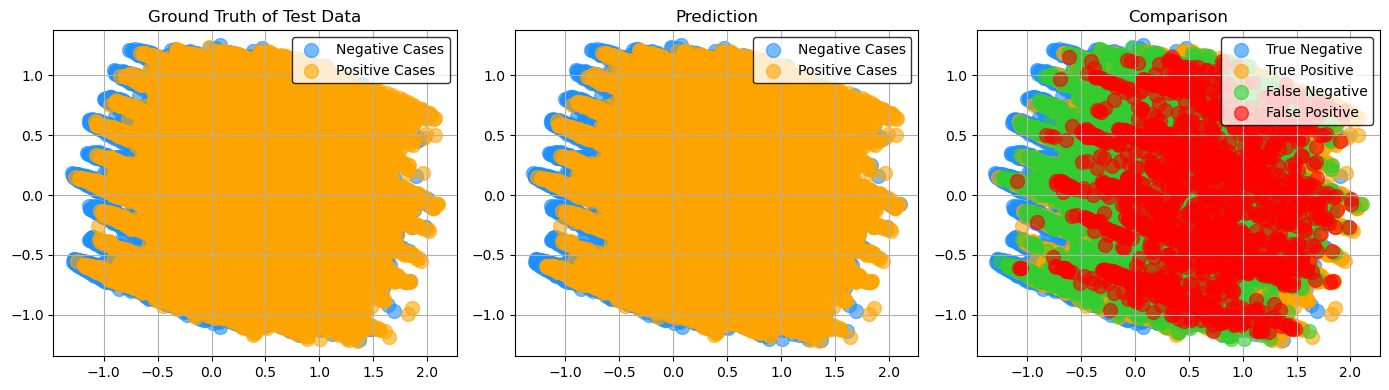

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def pca_plot(test_x_scaled, test_y, test_y_pred, size=100, markersize=1):
    pca = PCA(n_components=2)
    x_pca = pca.fit_transform(test_x_scaled)

    true_np = np.hstack((x_pca, test_y.reshape(len(test_y), 1)))
    pred_np = np.hstack((x_pca, test_y_pred.reshape(len(test_y_pred), 1)))

    column_true = ['pc_0', 'pc_1', 'true']
    column_pred = ['pc_0', 'pc_1', 'pred']

    true_df = pd.DataFrame(data=true_np, columns=column_true)
    pred_df = pd.DataFrame(data=pred_np, columns=column_pred)

    true_df_0 = true_df[true_df['true'] == 0]
    true_df_1 = true_df[true_df['true'] == 1]
    true_x_0 = true_df_0.iloc[:, :-1].to_numpy()
    true_x_1 = true_df_1.iloc[:, :-1].to_numpy()

    pred_df_0 = pred_df[pred_df['pred'] == 0]
    pred_df_1 = pred_df[pred_df['pred'] == 1]
    pred_x_0 = pred_df_0.iloc[:, :-1].to_numpy()
    pred_x_1 = pred_df_1.iloc[:, :-1].to_numpy()

    join_df = true_df.join(pred_df['pred'], rsuffix='_pred')

    correct_df = join_df[join_df['true'] == join_df['pred']]
    wrong_df = join_df[join_df['true'] != join_df['pred']]

    correct_df_0 = correct_df[correct_df['true'] == 0]
    correct_df_1 = correct_df[correct_df['true'] == 1]
    correct_x_0 = correct_df_0.iloc[:, :-2].to_numpy()
    correct_x_1 = correct_df_1.iloc[:, :-2].to_numpy()

    fn_df = wrong_df[wrong_df['pred'] == 0]
    fp_df = wrong_df[wrong_df['pred'] == 1]
    fn_x = fn_df.iloc[:, :-2].to_numpy()
    fp_x = fp_df.iloc[:, :-2].to_numpy()

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))

    # Plot Ground Truth
    ax1.scatter(true_x_0[:, 0], true_x_0[:, 1], c='dodgerblue', s=size, alpha=0.6, label='Negative Cases')
    ax1.scatter(true_x_1[:, 0], true_x_1[:, 1], c='orange', s=size, alpha=0.6, label='Positive Cases')
    ax1.legend(markerscale=markersize, loc='best', frameon=True, facecolor='white', edgecolor='black')
    ax1.set_title('Ground Truth of Test Data', fontsize=12)
    # ax1.set_xlabel('Principal Component 1', fontsize=12)
    # ax1.set_ylabel('Principal Component 2', fontsize=12)
    ax1.grid(True)

    # Plot Predictions
    ax2.scatter(pred_x_0[:, 0], pred_x_0[:, 1], c='dodgerblue', s=size, alpha=0.6, label='Negative Cases')
    ax2.scatter(pred_x_1[:, 0], pred_x_1[:, 1], c='orange', s=size, alpha=0.6, label='Positive Cases')
    ax2.legend(markerscale=markersize, loc='best', frameon=True, facecolor='white', edgecolor='black')
    ax2.set_title('Prediction', fontsize=12)
    # ax2.set_xlabel('Principal Component 1', fontsize=12)
    # ax2.set_ylabel('Principal Component 2', fontsize=12)
    ax2.grid(True)

    # Plot Comparison
    ax3.scatter(correct_x_0[:, 0], correct_x_0[:, 1], c='dodgerblue', s=size, alpha=0.6, label='True Negative')
    ax3.scatter(correct_x_1[:, 0], correct_x_1[:, 1], c='orange', s=size, alpha=0.6, label='True Positive')
    ax3.scatter(fn_x[:, 0], fn_x[:, 1], c='limegreen', s=size, alpha=0.6, label='False Negative')
    ax3.scatter(fp_x[:, 0], fp_x[:, 1], c='red', s=size, alpha=0.6, label='False Positive')
    ax3.legend(markerscale=markersize, loc='best', frameon=True, facecolor='white', edgecolor='black')
    ax3.set_title('Comparison', fontsize=12)
    # ax3.set_xlabel('Principal Component 1', fontsize=12)
    # ax3.set_ylabel('Principal Component 2', fontsize=12)
    ax3.grid(True)

    plt.tight_layout()
    plt.show()

# Example usage:
pca_plot(X_test, y_test, y_pred, size=100, markersize=1)
